# Programming in Python II - Final Coding Project

Author: Viktor Doychev

Student ID: k12441809

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [175]:
# This is just a minimum setup for reproducibility. Add more libraries as required.

import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import math

# Setting device
device = torch.device("cpu")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

from torch.utils.data import Dataset
from torch.utils.data import Subset
from torch.utils.data import DataLoader
import torch.nn as nn

from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import transforms
from copy import deepcopy
import tqdm

In [127]:
# checking successful setup
print(f"Using device: {device}")

Using device: cpu


In [3]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [4]:
# Set working directory to the project folder
os.chdir("/home/exvick/Desktop/Python_II/challenge/satellite-image-classification")  # Change this to your project folder path
print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/exvick/Desktop/Python_II/challenge/satellite-image-classification


In [5]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

#### Random seed for reproducing

In [36]:
random_state = 42

## Data Handling and Pre-Processing

In [50]:
# your code goes here (preprocess function)
def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:

    label_dict = {
        'HerbaceousVegetation': 0,
        'AnnualCrop': 1,
        'Residential': 2,
        'Pasture': 3,
        'Industrial': 4,
        'River': 5,
        'Highway': 6,
        'Forest': 7,
        'PermanentCrop': 8,
        'SeaLake': 9
    }

    folders = []
    file_names = []

    for root, dirs, files in os.walk(data_folder):
        for n in files:
            # print(root, n, root.rsplit("/", 1)[-1])
            folders.append(str(root))
            file_names.append(str(n)) 

    df = pd.DataFrame({"folder":folders,"file_name":file_names})
    df["label_str"] = df["folder"].apply(lambda x: x.rsplit("/", 1)[-1])
    df["label"] = df["label_str"].map(label_dict)
    df.drop(columns="label_str", inplace=True)

    return df, label_dict

dataset,labels_map = preprocess("/home/exvick/Desktop/Python_II/challenge/satellite-image-classification/data")
dataset

,folder,file_name,label
0,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_1131.jpg,2
1,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_1662.jpg,2
2,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_1120.jpg,2
3,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_1815.jpg,2
4,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_2768.jpg,2
...,...,...,...
9995,/home/exvick/Desktop/Python_II/challenge/satel...,River_575.jpg,5
9996,/home/exvick/Desktop/Python_II/challenge/satel...,River_1010.jpg,5
9997,/home/exvick/Desktop/Python_II/challenge/satel...,River_677.jpg,5
9998,/home/exvick/Desktop/Python_II/challenge/satel...,River_2380.jpg,5


In [35]:
# checking successful dataframe loading

# uncomment after preprocessing the dataset and adapt the variable name
print(f"Length of dataset: {len(dataset)}") # Should be 10000

Length of dataset: 10000


In [46]:
# your code goes here (splitting train/validation datasets)
X_train, X_val, y_train, y_val = train_test_split(
    dataset[["folder", "file_name"]], dataset["label"],
    test_size=0.2,
    random_state=random_state,
    stratify=dataset["label"]
)

## Exploratory Data Analysis (EDA)

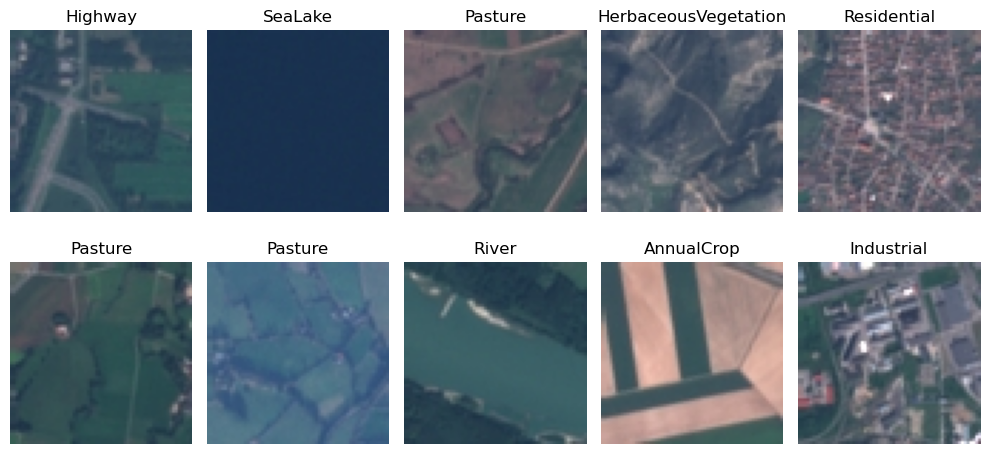

In [170]:
# your code goes here (show_samples)
def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:

    ds_sample = df.sample(n=num_samples, random_state=3)  
    
    cols = min(num_samples, 5)
    rows = math.ceil(num_samples / cols)
    plt.figure(figsize=(10,5))
    for i in range(0, cols * rows):
        img = Image.open(str(ds_sample.iloc[i].folder+"/"+ds_sample.iloc[i].file_name))
        label = ds_sample.iloc[i].file_name.split("_")[0]
        plt.subplot(rows, cols, i+1)
        plt.title(label)
        plt.axis("off")
        plt.imshow(img)
                
    plt.tight_layout()
    
    os.makedirs('assets/plots', exist_ok=True)
    plt.savefig('assets/plots/random_samples.png')

    plt.show()

show_samples(dataset, 10)

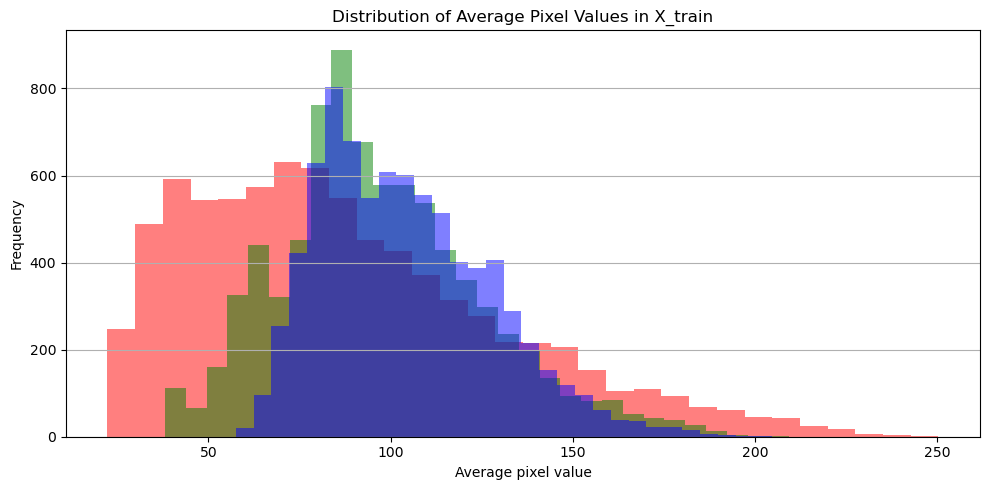

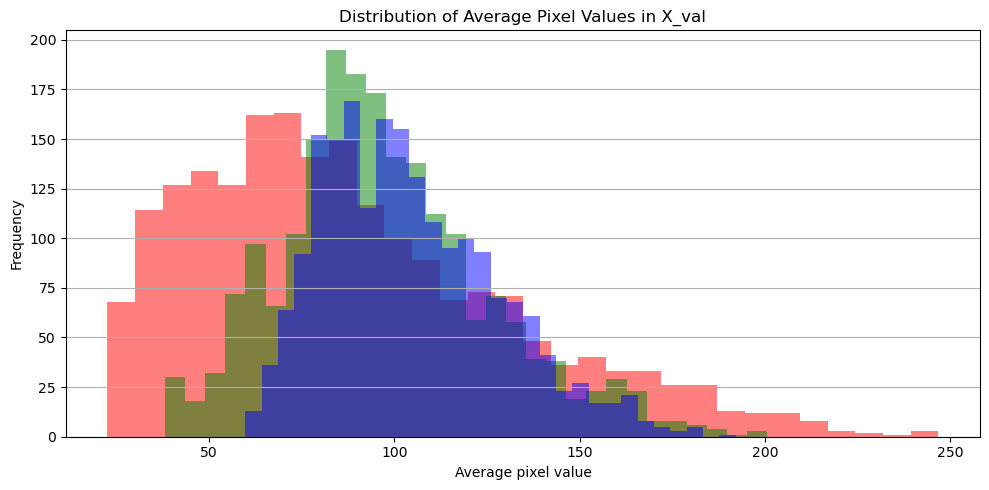

In [171]:
# your code goes here (average_pixel_plot)
def average_pixel_plot(df: pd.DataFrame, name: str) -> None:

    avg_r, avg_g, avg_b = [], [], []
    for i in range(len(df)):
        img = Image.open(str(df.iloc[i].folder+"/"+df.iloc[i].file_name))
        arr = np.array(img)
        # print(arr.shape)
        avg_r.append(arr[:,:,0].mean())
        avg_g.append(arr[:,:,1].mean())
        avg_b.append(arr[:,:,2].mean())

    plt.figure(figsize=(10,5))
    plt.hist(avg_r, bins=30, alpha=0.5, color="r")
    plt.hist(avg_g, bins=30, alpha=0.5, color="g")
    plt.hist(avg_b, bins=30, alpha=0.5, color="b")
    plt.title(f"Distribution of Average Pixel Values in {name}")
    plt.xlabel("Average pixel value")
    plt.ylabel("Frequency")
    plt.grid(axis="y")
    plt.tight_layout()

    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig(f"assets/plots/average_pixel_dictribution_{name}.png")

    plt.show()

average_pixel_plot(X_train, "X_train")
average_pixel_plot(X_val, "X_val")

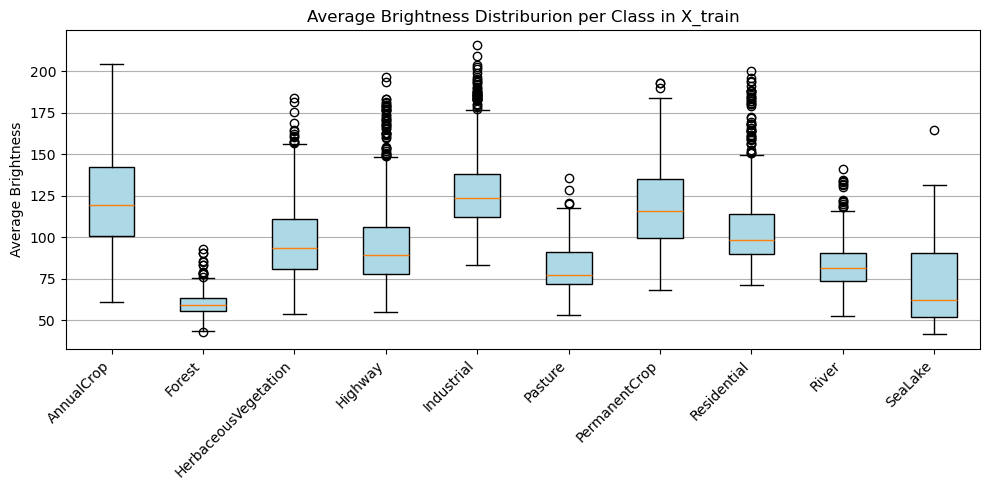

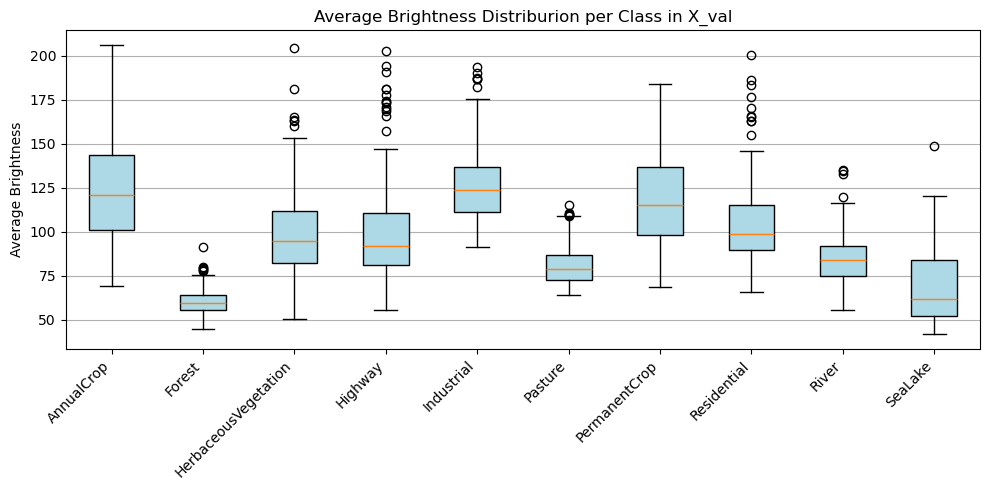

In [172]:
# your code goes here (average_brightness_per_class)
def average_brightness_per_class(df: pd.DataFrame, name: str) -> None:

    labels_all = []
    brightness_all = []
    for i in range(len(df)):
        img = Image.open(str(df.iloc[i].folder+"/"+df.iloc[i].file_name))
        label = df.iloc[i].file_name.split("_")[0]
        arr = np.array(img)
        labels_all.append(label)
        brightness_all.append(arr.mean())

    labels = sorted(set(labels_all))
    data = []
    for label in labels:
        data.append([brightness_all[i] for i in range(len(labels_all)) if labels_all[i] == label])

    plt.figure(figsize=(10,5))
    bp = plt.boxplot(data, labels=labels, patch_artist=True)
    for box in bp["boxes"]:
        box.set_facecolor("lightblue")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Average Brightness Distriburion per Class in {name}")
    plt.ylabel("Average Brightness")
    plt.grid(axis="y")
    plt.gca().set_axisbelow(True)
    plt.tight_layout()

    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig(f"assets/plots/average_brightness_{name}.png")

    plt.show()

average_brightness_per_class(X_train, "X_train")
average_brightness_per_class(X_val, "X_val")

## CNN Implementation and Training

DISCLAIMER: I am very much inspired from the lecture material notebooks, so my implementation can be pretty similar to the things shown to us.

### Dataset class

In [113]:
# your code goes here
class SatelliteDataset(Dataset):
    def __init__(self, X_df, y_df, transform=None):

        self.X_df = X_df
        self.y_df = y_df
        self.transform = transform
        
    
    def __len__(self):
        return len(self.X_df)
    
    def __getitem__(self, i):
        path = str(self.X_df.iloc[i].folder+"/"+self.X_df.iloc[i].file_name)
        label = int(self.y_df.iloc[i])

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        
        return img, label


I added a new function to calculate the mean and std per channel for the images so that I can normalize them down with the transformations:

In [120]:
def mean_std_brightness(df: pd.DataFrame):

    sum_r, sum_sq_r, n_r = 0.0, 0.0, 0
    sum_g, sum_sq_g, n_g = 0.0, 0.0, 0
    sum_b, sum_sq_b, n_b = 0.0, 0.0, 0
    for i in range(len(df)):
        img = Image.open(str(df.iloc[i].folder+"/"+df.iloc[i].file_name))
        arr = np.array(img)/255

        r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
        sum_r += r.sum(); sum_sq_r += (r.astype(np.float64)**2).sum(); n_r += r.size
        sum_g += g.sum(); sum_sq_g += (g.astype(np.float64)**2).sum(); n_g += g.size
        sum_b += b.sum(); sum_sq_b += (b.astype(np.float64)**2).sum(); n_b += b.size

    mean_r = sum_r / n_r
    mean_g = sum_g / n_g
    mean_b = sum_b / n_b
    std_r = np.sqrt(sum_sq_r / n_r - mean_r**2)
    std_g = np.sqrt(sum_sq_g / n_g - mean_g**2)
    std_b = np.sqrt(sum_sq_b / n_b - mean_b**2)

    return (mean_r, mean_g,mean_b), (std_r, std_g, std_b)

mean, std = mean_std_brightness(X_train)
mean, std

((0.34372076990464207, 0.3811175644818459, 0.40848065640318615),
 (0.20149977112034764, 0.13648379098261232, 0.11620906916470537))

In [121]:
train_tfms = transforms.Compose([
    transforms.Resize((64, 64)),  # the size of the satellite images
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomChoice(
        [
            transforms.RandomRotation((0, 0)),
            transforms.RandomRotation((90, 90)),
            transforms.RandomRotation((180, 180)),
            transforms.RandomRotation((270, 270)),
        ]
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_tfms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds = SatelliteDataset(X_train, y_train, train_tfms)
val_ds = SatelliteDataset(X_val, y_val, val_tfms)

### Data Loaders

In [148]:
# your code goes here
train_loader = DataLoader(dataset=train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(dataset=val_ds, batch_size=32, shuffle=False, num_workers=4)

In [146]:
next(iter(train_loader))[0].shape

torch.Size([32, 3, 64, 64])

shape of the batch looks correct - batch size X channels X resolution

### Model Architecture

In [138]:
# your code goes here
class SatelliteCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # [3,64,64] -> [32,64,64]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # [32,64,64] -> [32,32,32]
        )
        self.vgg_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # [32,32,32] -> [64,32,32]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2), # [64,32,32]->[64,16,16]
        )
        self.vgg_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # [64,16,16] -> [128,16,16]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2), # [128,16,16] -> [128,8,8]
        )
        self.linear_stack = nn.Sequential(
            nn.Linear(128*8*8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self, x):
        x = self.vgg_block1(x)
        x = self.vgg_block2(x)
        x = self.vgg_block3(x)
        x = torch.flatten(x, 1) # [batch,128,8,8] -> [batch,128*8*8]  
        x = self.linear_stack(x)
        return x


### Training Loop

In [156]:
model = SatelliteCNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

a bit higher lr cause on cpu (time is bottleneck) - so I hope the net will learn faster

In [157]:
# your code goes here
# I readapted code from the notebooks on torch 

num_epochs = 200
early_stopping = 9  

train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_acc = -1
best_model_params = None
epoch_with_best_val_acc = 0
os.makedirs("assets/weights", exist_ok=True)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    scheduler.step(val_accuracy)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    train_accs.append(train_accuracy)
    val_losses.append(val_loss)
    val_accs.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f} "
          f"current lr: {current_lr}"
          )
    
    if val_accuracy > best_acc:
        best_acc = val_accuracy
        best_model_params = deepcopy(model.state_dict())
        epoch_with_best_val_acc = epoch
        torch.save(best_model_params, "assets/weights/best_model_params.pth")
        
    if epoch > 0 and epoch - epoch_with_best_val_acc >= early_stopping:
        print(f"Early stopping at epoch {epoch + 1}.\n")
        break

Epoch 1/200:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/200: 100%|██████████| 250/250 [00:35<00:00,  7.12it/s]


Epoch [1/200], Train Loss: 1.4342, Train Accuracy: 0.4985, Val Loss: 0.8800, Val Accuracy: 0.6950 current lr: 0.001


Epoch 2/200: 100%|██████████| 250/250 [00:35<00:00,  7.07it/s]


Epoch [2/200], Train Loss: 1.1040, Train Accuracy: 0.6086, Val Loss: 0.8095, Val Accuracy: 0.7210 current lr: 0.001


...

Epoch [56/200], Train Loss: 0.2653, Train Accuracy: 0.9106, Val Loss: 0.1982, Val Accuracy: 0.9325 current lr: 1.953125e-06


Epoch 57/200: 100%|██████████| 250/250 [00:38<00:00,  6.42it/s]


Epoch [57/200], Train Loss: 0.2662, Train Accuracy: 0.9094, Val Loss: 0.2029, Val Accuracy: 0.9315 current lr: 1.953125e-06


Epoch 58/200: 100%|██████████| 250/250 [00:38<00:00,  6.53it/s]


Epoch [58/200], Train Loss: 0.2612, Train Accuracy: 0.9139, Val Loss: 0.1996, Val Accuracy: 0.9325 current lr: 9.765625e-07
Early stopping at epoch 58.



In [154]:
print(train_losses,train_accs,val_losses,val_accs)

[1.0374548163414001, 0.9433586906194686, 0.8692710303068161, 0.8498518970012665, 0.806269378900528, 0.7564248721599579] [0.63075, 0.670625, 0.696375, 0.705, 0.721375, 0.73825] [0.7576010927321419, 0.6793196144558135, 0.7063142846501063, 0.695828031925928, 0.6368467538129716, 0.6047913654456063] [0.7225, 0.7615, 0.7415, 0.7465, 0.7755, 0.774]


## Model Evaluation

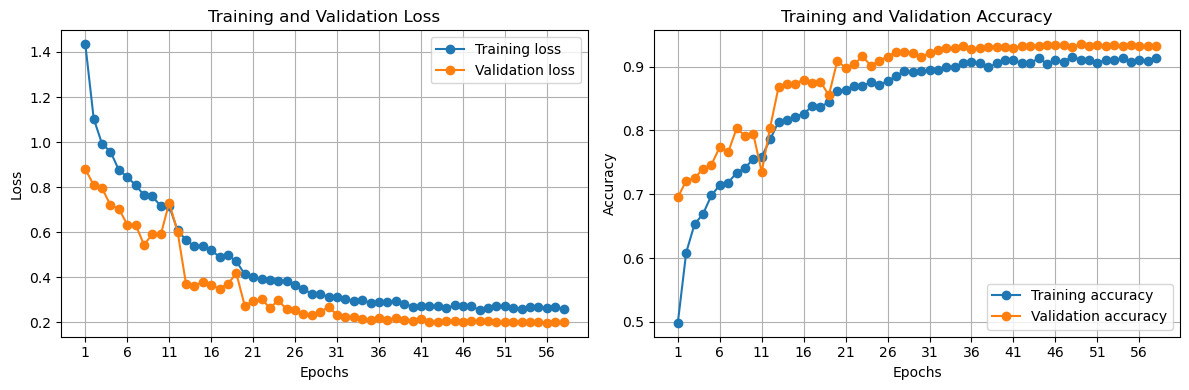

In [169]:
# your code goes here (plot_training_curves)
def plot_training_curves(train_losses, val_losses, train_accs, val_accs) -> None:

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training loss", marker="o")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation loss", marker="o")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.xticks(range(1, len(train_losses) + 1, 5))
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(train_accs) + 1), train_accs, label="Training accuracy", marker="o")
    plt.plot(range(1, len(val_accs) + 1), val_accs, label="Validation accuracy", marker="o")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.xticks(range(1, len(train_accs) + 1, 5))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    os.makedirs('assets/plots', exist_ok=True)
    plt.savefig('assets/plots/training_curves.png')

    plt.show()

plot_training_curves(train_losses, val_losses, train_accs, val_accs)

In [177]:
state_dict = torch.load("assets/weights/best_model_params.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        true_labels.append(labels.cpu().numpy())
        pred_labels.append(preds.cpu().numpy())

true_labels = np.concatenate(true_labels)
pred_labels = np.concatenate(pred_labels)

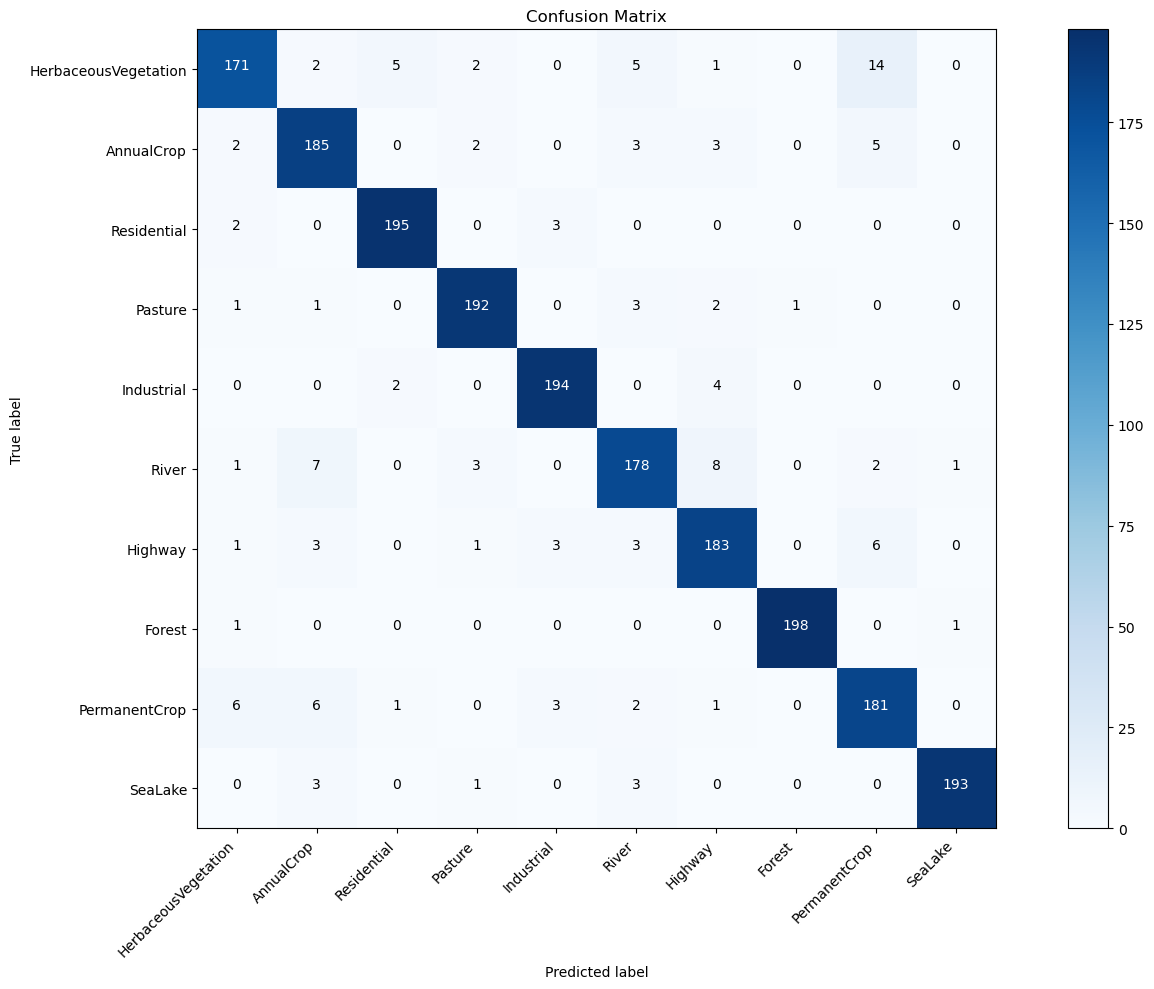

In [189]:
# your code goes here (plot_confusion_matrix)
def plot_confusion_matrix(cm, classes, figsize=(15, 10), title='Confusion Matrix'):
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    threshold = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > threshold else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.colorbar()
    plt.tight_layout()

    os.makedirs('assets/plots', exist_ok=True)
    plt.savefig("assets/plots/confusion_matrix_CL.png")

    plt.show()
    plt.close()

cm = confusion_matrix(true_labels, pred_labels)

classes = [name for name, idx in sorted(label_dict.items(), key=lambda kv: kv[1])]
plot_confusion_matrix(cm, classes)

In [183]:
wrong_idx = np.where(true_labels != pred_labels)[0]
wrong_idx[:5]

array([ 47,  59,  75,  79, 121])

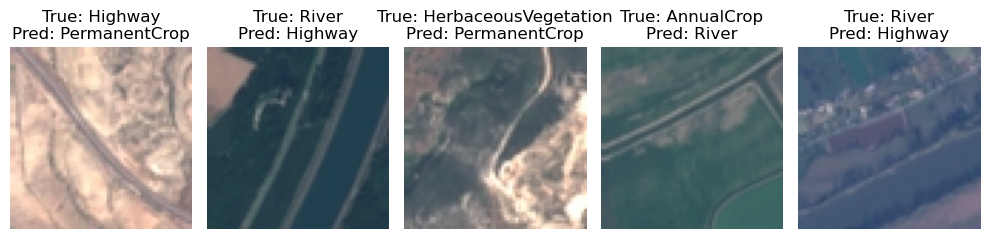

In [190]:
# your code goes here (plot_misclassified_samples)
def plot_misclassified_samples(df, wrong_idx, true_labels, pred_labels, classes, num_samples=5):

    # future proof - if the model becomes almost perfect:
    num_samples = min(num_samples, len(wrong_idx))
    sel = wrong_idx[:num_samples]
    
    ds_sample = df.iloc[wrong_idx[:num_samples]]  
    
    cols = min(num_samples, 5)
    rows = math.ceil(num_samples / cols)
    plt.figure(figsize=(10,5))
    for i, k in enumerate(sel):
        row = df.iloc[k]
        img = Image.open(str(row.folder + "/" + row.file_name)).convert("RGB")
        true_name = classes[true_labels[k]]
        pred_name = classes[pred_labels[k]]
        plt.subplot(rows, cols, i + 1)
        plt.title(f"True: {true_name}\nPred: {pred_name}")
        plt.axis("off")
        plt.imshow(img)
                
    plt.tight_layout()
    
    os.makedirs('assets/plots', exist_ok=True)
    plt.savefig('assets/plots/missclassified_samples.png')

    plt.show()

plot_misclassified_samples(X_val, wrong_idx, true_labels, pred_labels, classes)

### Test Set

In [ ]:
# your code goes here (preprocess_test_data)


In [ ]:
# your code goes here (create dataset and dataloader)

In [ ]:
# your code goes here (evaluate model on test set)

In [ ]:
# your code goes here (create submission csv file for challenge server)